## 一、一元线性回归

### 1.理论模型

一元线性回归模型

$$
y_i = \beta_0 + \beta_1 x_i + \varepsilon_i
$$

其中：

- $y_i$：因变量
- $x_i$：自变量
- $(\beta_0, \beta_1)$：参数
- $\varepsilon_i$：随机误差项



经典线性回归模型（CLRM）假设

- 线性可估：模型关于参数为线性形式 $y_i = \beta_0 + \beta_1 x_i + \varepsilon_i$
- 误差项期望为零：$\mathbb{E}(\varepsilon_i) = 0$
- 同方差性：$\mathrm{Var}(\varepsilon_i) = \sigma^2$
- 误差项无自相关：$\mathrm{Cov}(\varepsilon_i, \varepsilon_j) = 0$
- 自变量非随机或与误差项独立：$\mathrm{Cov}(x_i, \varepsilon_i)=0$
- 误差项正态分布（用于 t 检验与 F 检验）：$\varepsilon_i \sim \mathcal{N}(0, \sigma^2)$


### 2.参数估计（OLS）

OLS 估计量为：

$$
\hat{\beta}_1 = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}
$$

$$
\hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}
$$


### 3.检验

(1) t 检验（单个参数）

检验原假设：

$$
H_0:\ \beta_1 = 0
$$

t 统计量：

$$
t=\frac{\hat{\beta}_1}{SE(\hat{\beta}_1)}
$$

比较 t 值或 p 值判断是否拒绝原假设。


(2) F 检验（整体显著性）

对于一元回归，F 检验等价于 t 检验：

$$
F = t^2
$$


(3) 拟合优度 $R^2$

$$
R^2 = 1 - \frac{SSR}{SST}
$$


合并后的数据预览：
    Year  Gdp0109  BirthRate
0   1952    119.0      37.00
5   1957    168.0      34.03
10  1962    175.0      37.01
13  1965    242.0      37.88
18  1970    279.0      33.43

回归结果：

                            OLS Regression Results                            
Dep. Variable:              BirthRate   R-squared:                       0.468
Model:                            OLS   Adj. R-squared:                  0.465
Method:                 Least Squares   F-statistic:                     122.5
Date:                Sun, 14 Dec 2025   Prob (F-statistic):           8.19e-21
Time:                        16:28:29   Log-Likelihood:                -399.91
No. Observations:                 141   AIC:                             803.8
Df Residuals:                     139   BIC:                             809.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 c

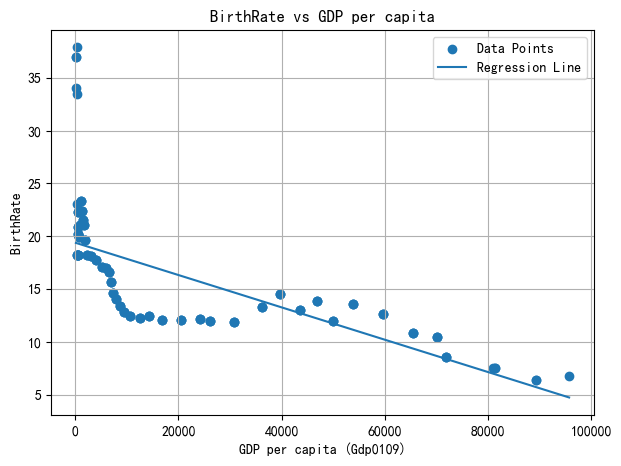

In [3]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.family'] = 'sans-serif'       # 全局字体类别 
plt.rcParams['font.sans-serif'] = ['SimHei']     # 具体字体：黑体 
plt.rcParams['axes.unicode_minus'] = False       # 解决负号无法显示的问题

# =============================================================
# 1. 读入两个 CSV 文件
# =============================================================
pop_path = r"EIC_PopulationY.csv"   # 出生率数据
gdp_path = r"CME_Gdp1.csv"          # 人均GDP数据   

df_pop = pd.read_csv(pop_path, encoding='utf-8')
df_gdp = pd.read_csv(gdp_path, encoding='utf-8')

# =============================================================
# 2. 重命名列
# =============================================================
df_pop = df_pop.rename(columns={"SgnYear": "Year"})
df_gdp = df_gdp.rename(columns={"Sgnyea": "Year"})

# =============================================================
# 3. 合并出生率和 GDP 数据
# =============================================================
df = pd.merge(df_pop, df_gdp, on="Year", how="inner")

# 只保留 GDP & 出生率 列
df = df[["Year", "Gdp0109", "BirthRate"]]
df = df.dropna()

print("合并后的数据预览：")
print(df.head())

# =============================================================
# 4. 一元线性回归 BirthRate ~ GDP
# =============================================================
y = df["BirthRate"]
X = df[["Gdp0109"]]
X = sm.add_constant(X)        # 加常数项

model = sm.OLS(y, X).fit()
print("\n回归结果：\n")
print(model.summary())

# =============================================================
# 5. 绘图（散点图 + 回归线）
# =============================================================

plt.figure(figsize=(7, 5))
plt.scatter(df["Gdp0109"], df["BirthRate"], label="Data Points")

# 画回归线
x_line = pd.Series(sorted(df["Gdp0109"]))
X_line = sm.add_constant(x_line)
y_pred_line = model.predict(X_line)

plt.plot(x_line, y_pred_line, label="Regression Line")

plt.title("BirthRate vs GDP per capita")
plt.xlabel("GDP per capita (Gdp0109)")
plt.ylabel("BirthRate")
plt.grid(True)
plt.legend()
plt.show()


## 二、二元线性回归（Multiple Linear Regression, k=2）

### 1. 理论模型

常见例子：工资与教育年限、工作经验

$$
y_i = \beta_0 + \beta_1 x_{1i} + \beta_2 x_{2i} + \varepsilon_i
$$

$$
wage = \beta_0 + \beta_1 education + \beta_2 experience + \varepsilon
$$


---

### 2. 参数估计（OLS）

考虑二元线性回归模型：

$$
y_i = \beta_0 + \beta_1 x_{1i} + \beta_2 x_{2i} + \varepsilon_i
$$

其矩阵形式为：

$$
y = X\beta + \varepsilon
$$

其中：

$$
X = 
\begin{pmatrix}
1 & x_{11} & x_{21} \\
1 & x_{12} & x_{22} \\
\vdots & \vdots & \vdots \\
1 & x_{1n} & x_{2n} 
\end{pmatrix},
\qquad
\beta =
\begin{pmatrix}
\beta_0 \\[6pt]
\beta_1 \\[6pt]
\beta_2
\end{pmatrix},
\qquad
y =
\begin{pmatrix}
y_1 \\ y_2 \\ \vdots \\ y_n
\end{pmatrix}
$$

OLS 的目标是最小化残差平方和：

$$
S(\beta) = (y - X\beta)'(y - X\beta)
$$

对 \(S(\beta)\) 对 \(\beta\) 求导并令导数为零，可得正规方程：

$$
X'X\hat{\beta} = X'y
$$

从而得到 OLS 闭式解：

$$
\hat{\beta} = (X'X)^{-1}X'y
$$

若进一步展开三维情形（截距 + 两个解释变量），令：

$$
X'X =
\begin{pmatrix}
n & \sum x_{1i} & \sum x_{2i} \\
\sum x_{1i} & \sum x_{1i}^2 & \sum x_{1i}x_{2i} \\
\sum x_{2i} & \sum x_{1i}x_{2i} & \sum x_{2i}^2
\end{pmatrix},
\qquad
X'y =
\begin{pmatrix}
\sum y_i \\
\sum x_{1i}y_i \\
\sum x_{2i}y_i
\end{pmatrix}
$$

因此：

$$
\hat{\beta} =
\begin{pmatrix}
\hat{\beta}_0 \\[4pt]
\hat{\beta}_1 \\[4pt]
\hat{\beta}_2
\end{pmatrix}
=
(X'X)^{-1}
\begin{pmatrix}
\sum y_i \\
\sum x_{1i}y_i \\
\sum x_{2i}y_i
\end{pmatrix}
$$

---


### 3. 检验

#### （1）单个系数的 t 检验

$$
H_0:\ \beta_j = 0
$$


#### （2）多个系数的 F 检验

例如检验：

$$
H_0:\ \beta_1 = \beta_2 = 0
$$

F 统计量来自回归输出。


#### （3）多重共线性检验

常用 VIF：

$$
VIF_j = \frac{1}{1 - R_j^2}
$$

若 VIF > 10，一般认为存在严重共线性。


合并后的数据：
   Year  BirthRate  Gdp0109  Avhlcst
0  1978      18.25   384.74    11.45
1  1978      18.25   384.74    11.45
2  1978      18.25   384.74    11.45
3  1978      18.25   384.74    11.45
4  1978      18.25   384.74    11.45

回归结果：
                            OLS Regression Results                            
Dep. Variable:              BirthRate   R-squared:                       0.656
Model:                            OLS   Adj. R-squared:                  0.654
Method:                 Least Squares   F-statistic:                     504.2
Date:                Sun, 14 Dec 2025   Prob (F-statistic):          2.26e-123
Time:                        12:50:27   Log-Likelihood:                -1233.3
No. Observations:                 533   AIC:                             2473.
Df Residuals:                     530   BIC:                             2485.
Df Model:                           2                                         
Covariance Type:            nonrobust               

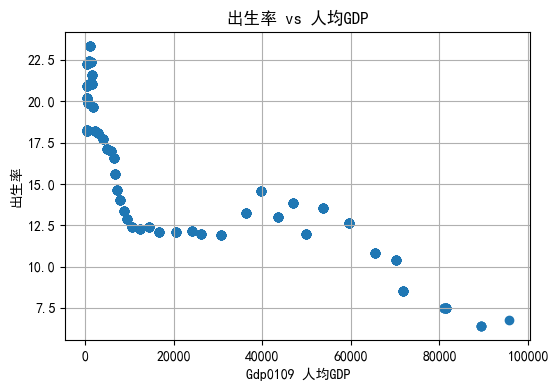

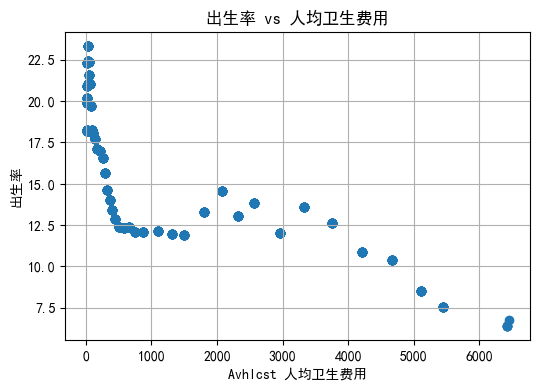

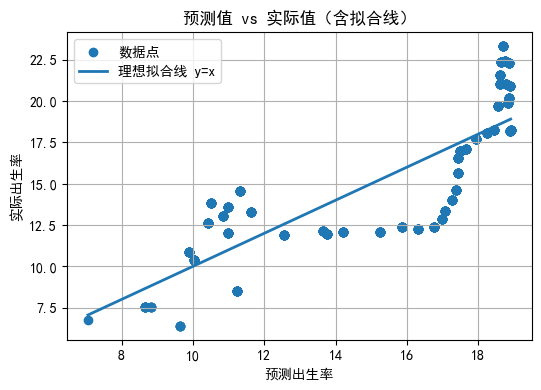

In [2]:
# ---------------------------------------------------------
# 1. 导入库
# ---------------------------------------------------------
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

# ---------------------------------------------------------
# 2. 读取三个 CSV
# ---------------------------------------------------------
pop_path = r"EIC_PopulationY.csv"   # 出生率数据
gdp_path = r"CME_Gdp1.csv"          # 人均GDP数据
health_path = r"CPID_Hlthfs.csv"    #人均医疗卫生费用

df_pop = pd.read_csv(pop_path, encoding='utf-8')
df_gdp = pd.read_csv(gdp_path, encoding='utf-8')
df_health = pd.read_csv(health_path, encoding='utf-8')

# ---------------------------------------------------------
# 3. 重命名年份列
# ---------------------------------------------------------
df_pop = df_pop.rename(columns={"SgnYear": "Year"})
df_gdp = df_gdp.rename(columns={"Sgnyea": "Year"})
df_health = df_health.rename(columns={"Sgnyea": "Year"})

# ---------------------------------------------------------
# 4. 合并数据
# ---------------------------------------------------------
df = pd.merge(df_pop, df_gdp, on="Year", how="inner")
df = pd.merge(df, df_health, on="Year", how="inner")

# ---------------------------------------------------------
# 5. 选择需要的列
# ---------------------------------------------------------
df = df[["Year", "BirthRate", "Gdp0109", "Avhlcst"]]

print("合并后的数据：")
print(df.head())

# ---------------------------------------------------------
# 6. 二元线性回归
# ---------------------------------------------------------
X = df[["Gdp0109", "Avhlcst"]]
X = sm.add_constant(X)
y = df["BirthRate"]

model = sm.OLS(y, X).fit()
print("\n回归结果：")
print(model.summary())

# ---------------------------------------------------------
# 7. VIF 共线性检验
# ---------------------------------------------------------
vif_df = pd.DataFrame()
vif_df["Variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("\nVIF（共线性检验）：")
print(vif_df)

# ---------------------------------------------------------
# 8. 绘图部分
# ---------------------------------------------------------

# 图1：出生率 vs 人均GDP（无拟合线）
plt.figure(figsize=(6,4))
plt.scatter(df["Gdp0109"], df["BirthRate"])
plt.xlabel("Gdp0109 人均GDP")
plt.ylabel("出生率")
plt.title("出生率 vs 人均GDP")
plt.grid(True)
plt.show()

# 图2：出生率 vs 人均卫生费用（无拟合线）
plt.figure(figsize=(6,4))
plt.scatter(df["Avhlcst"], df["BirthRate"])
plt.xlabel("Avhlcst 人均卫生费用")
plt.ylabel("出生率")
plt.title("出生率 vs 人均卫生费用")
plt.grid(True)
plt.show()

# 图3：预测值 vs 实际值（带拟合线 y=x）
df["Predicted"] = model.predict(X)

plt.figure(figsize=(6,4))
plt.scatter(df["Predicted"], df["BirthRate"], label="数据点")
plt.plot(df["Predicted"], df["Predicted"], linewidth=2, label="理想拟合线 y=x")
plt.xlabel("预测出生率")
plt.ylabel("实际出生率")
plt.title("预测值 vs 实际值（含拟合线）")
plt.legend()
plt.grid(True)
plt.show()
